# Extract the file from compression

In [1]:
import gzip
import shutil

with gzip.open('wiki-Vote.txt.gz', 'rb') as f_in:
    with open('wiki-Vote.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Extraction complete!")

Extraction complete!


# Convert the file from txt to tsv for cytoscape

In [2]:
import pandas as pd

edges = []

with open('Wiki-Vote.txt', 'r') as f:
    for line in f:
        line = line.strip()
        # Skip comment lines and empty lines
        if not line or line.startswith('#'):
            continue
        parts = line.split()  # split by any whitespace
        if len(parts) == 2:
            source, target = parts
            edges.append([source, target])  # keep as strings to avoid Excel formatting

# Create DataFrame
df = pd.DataFrame(edges, columns=['Source', 'Target'])

# Save as TSV (tab-separated)
df.to_csv('Wiki-Vote.tsv', sep='\t', index=False)

print("TXT converted to TSV successfully with 'Source' and 'Target' columns!")

TXT converted to TSV successfully with 'Source' and 'Target' columns!


# Number of Nodes , Edges

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Build a directed graph
G = nx.DiGraph()
G.add_edges_from(df.values)

print("Graph loaded:")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Graph loaded:
Nodes: 7115
Edges: 103689


# Determine whether the network is dense or sparse 

In [6]:
import networkx as nx

N = G.number_of_nodes()
E = G.number_of_edges()
# Maximum possible directed edges
max_edges = N * (N - 1)

# Density calculation
density = E / max_edges

print(f"Maximum possible edges N(N-1): {max_edges:,}")
print(f"Density: {density:.8f}")

#classify
if density >= 0.1:
    print("The network is dense.")
elif density >= 0.01:
    print("The network is sparse.")
else:
    print("The network is VERY sparse.")


Maximum possible edges N(N-1): 50,616,110
Density: 0.00204854
The network is VERY sparse.


# Connectivity of the network 

In [7]:
# For undirected connectivity
is_connected = nx.is_connected(G.to_undirected())

# For directed graph: strong connectivity
is_strongly_connected = nx.is_strongly_connected(G)

print("Connected (ignoring direction):", is_connected)
print("Strongly connected:", is_strongly_connected)

Connected (ignoring direction): False
Strongly connected: False


# Strongly connected component

In [8]:
if nx.is_strongly_connected(G):
    avg_shortest_path = nx.average_shortest_path_length(G)
    print("Graph is strongly connected")
else:
    # Use the largest strongly connected component
    largest_scc = max(nx.strongly_connected_components(G), key=len)
    G_scc = G.subgraph(largest_scc)
    avg_shortest_path = nx.average_shortest_path_length(G_scc)
    print(f"Graph is not strongly connected. Using largest SCC with {len(G_scc)} nodes")


Graph is not strongly connected. Using largest SCC with 1300 nodes


# Node attributes

They can be any property attached to a node.

Network analysis gives each node numerical measures describing its role in the network. These measures are just special node attributes.
e.g Indegree , Outdegree , Total Degree , Stress , Eccentricity

# Degree

- In-Degree : Measures how many edges are coming into a node
- Out-Degree : Measures how many edges are going out of a node
- Total Degree:Simply in-degree + out-degree normalized, Gives an overall sense of how connected a node is.

In [9]:
import networkx as nx
import pandas as pd

# Compute degrees correctly
indegree = dict(G.in_degree())
outdegree = dict(G.out_degree())
total_degree = dict(G.degree())  

# Make DataFrame
df = pd.DataFrame({
    "Node": list(G.nodes()),
    "Indegree": [indegree[n] for n in G.nodes()],
    "Outdegree": [outdegree[n] for n in G.nodes()],
    "Total Degree": [total_degree[n] for n in G.nodes()]
})

# Optional: sort by indegree
df_sorted = df.sort_values("Indegree", ascending=False)
df_sorted.head(10)


,Node,Indegree,Outdegree,Total Degree
326,4037,457,15,472
409,15,361,50,411
905,2398,340,62,402
711,2625,331,0,331
247,1297,309,76,385
699,2565,274,893,1167
432,762,272,50,322
666,2328,266,215,481
3,5254,265,33,298
2,3352,264,273,537


In [10]:
# plotting it to be more readable 
df["Node"] = df["Node"].astype(int)
nodes_to_plot = [4037, 15, 2398, 2625, 1297, 2565, 762, 2328, 5254, 3352] #choosing the nodes appeared in the previous table

df_top10 = df[df["Node"].isin(nodes_to_plot)]

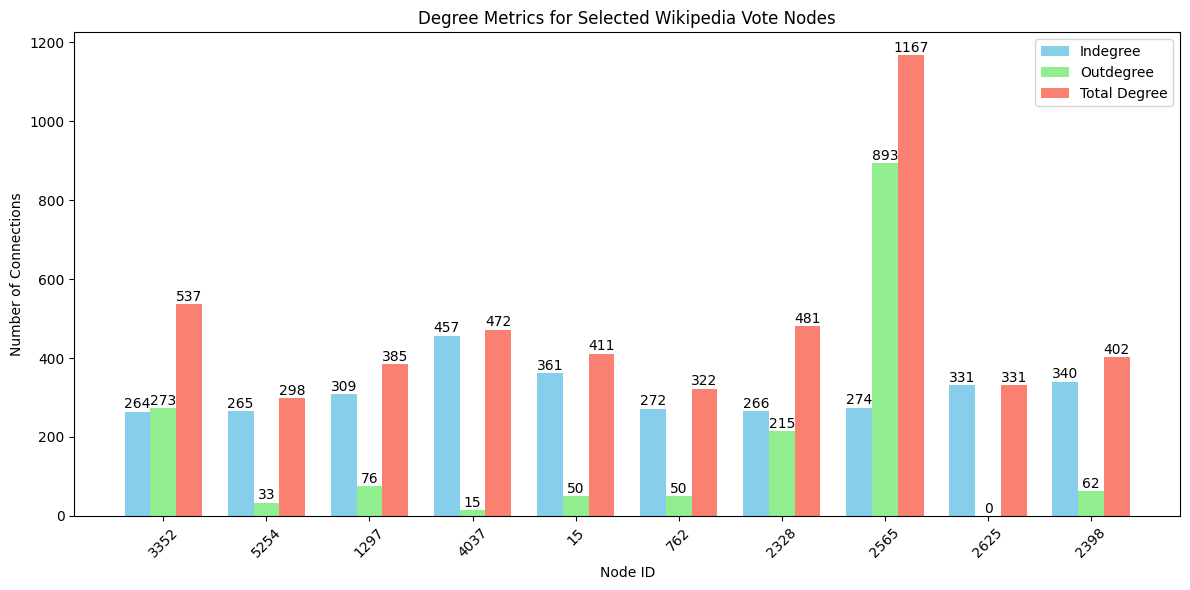

In [11]:
import matplotlib.pyplot as plt

x = range(len(df_top10))
width = 0.25  # width of each bar

plt.figure(figsize=(12,6))

# Plot bars
bars_indegree = plt.bar([i - width for i in x], df_top10["Indegree"], width=width, color='skyblue', label='Indegree')
bars_outdegree = plt.bar(x, df_top10["Outdegree"], width=width, color='lightgreen', label='Outdegree')
bars_total = plt.bar([i + width for i in x], df_top10["Total Degree"], width=width, color='salmon', label='Total Degree')

plt.xticks(x, df_top10["Node"], rotation=45)
plt.xlabel("Node ID")
plt.ylabel("Number of Connections")
plt.title("Degree Metrics for Selected Wikipedia Vote Nodes")
plt.legend()
plt.tight_layout()

# Add value labels on top of each bar
for bars in [bars_indegree, bars_outdegree, bars_total]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom')

plt.show()


# Average degree

It is the mean number of connections per node in a network. It gives a sense of how connected the nodes are on average

In [12]:
num_nodes = G.number_of_nodes()

# Compute in-degree and out-degree dictionaries
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Average in-degree
avg_in_degree = sum(in_degrees.values()) / num_nodes

# Average out-degree
avg_out_degree = sum(out_degrees.values()) / num_nodes

# Average total degree
avg_total_degree = sum(in_degrees.values()) + sum(out_degrees.values())
avg_total_degree /= num_nodes

print("Average in-degree:", avg_in_degree)
print("Average out-degree:", avg_out_degree)
print("Average total degree:", avg_total_degree)

Average in-degree: 14.573295853829936
Average out-degree: 14.573295853829936
Average total degree: 29.146591707659873


note : In a directed network, the sum of in-degrees = sum of out-degrees = total number of edges.

In [13]:
max_in_node = max(G.in_degree(), key=lambda x: x[1])
print("Node with highest in-degree:", max_in_node)

# Find node with max out-degree
max_out_node = max(G.out_degree(), key=lambda x: x[1])
print("Node with highest out-degree:", max_out_node)


Node with highest in-degree: ('4037', 457)
Node with highest out-degree: ('2565', 893)


# Eccentricity

Maximum shortest-path distance from this node to any other reachable node( measures how far a node is from its farthest reachable node) 
while diameter is the maximum eccentricity over all nodes in the graph.

- Lower eccentricity → node is closer to everyone.
- Higher eccentricity → node is far from some parts of the network.

In [14]:
import networkx as nx
import pandas as pd


# Take the largest strongly connected component
largest_scc_nodes = max(nx.strongly_connected_components(G), key=len)
G_scc = G.subgraph(largest_scc_nodes)

# Compute eccentricity
ecc_dict = nx.eccentricity(G_scc)

# Convert to DataFrame
df_ecc = pd.DataFrame.from_dict(ecc_dict, orient='index', columns=['Eccentricity'])
df_ecc.index.name = 'Node'
df_ecc.reset_index(inplace=True)

df_ecc.head(10)


,Node,Eccentricity
0,7407,6
1,6229,5
2,856,4
3,6523,4
4,6006,4
5,1403,6
6,3191,4
7,338,6
8,371,4
9,791,4


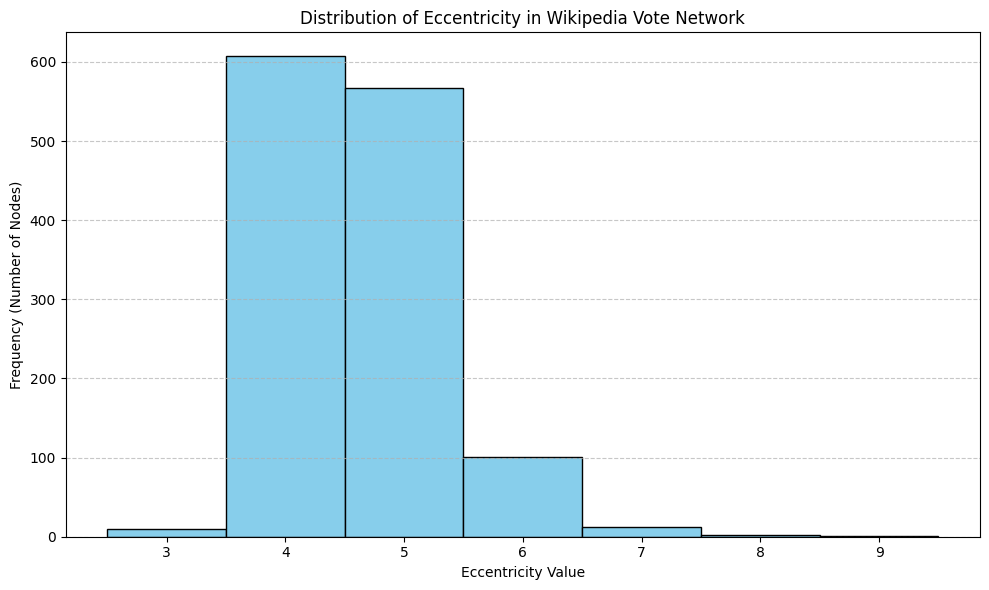

In [15]:
#Plot histogram of eccentricity

plt.figure(figsize=(10,6))
plt.hist(df_ecc["Eccentricity"], bins=range(df_ecc["Eccentricity"].min(), df_ecc["Eccentricity"].max()+2),
         color='skyblue', edgecolor='black', align='left')
plt.xlabel("Eccentricity Value")
plt.ylabel("Frequency (Number of Nodes)")
plt.title("Distribution of Eccentricity in Wikipedia Vote Network")
plt.xticks(range(df_ecc["Eccentricity"].min(), df_ecc["Eccentricity"].max()+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Components

In [16]:
strongly_connected_components = nx.number_strongly_connected_components(G)
weakly_connected_components = nx.number_weakly_connected_components(G)
largest_component = max(nx.weakly_connected_components(G), key=len)

print("Strongly connected components:", strongly_connected_components) #a subset of nodes where every node can reach every other node following the direction of edges.
print("Weakly connected components (Connected Components):", weakly_connected_components) #a subset where nodes are connected if we ignore edge direction.
print("Largest component size:", len(largest_component))

Strongly connected components: 5816
Weakly connected components (Connected Components): 24
Largest component size: 7066


# Community Detection

In [17]:
import community as community_louvain  

# Compute best partition (communities) , real one 
partition = community_louvain.best_partition(G.to_undirected())

print("First 10 nodes and their communities:")
for node, comm in list(partition.items())[:10]:
    print(f"Node {node} → Community {comm}")

First 10 nodes and their communities:
Node 30 → Community 0
Node 1412 → Community 1
Node 3352 → Community 2
Node 5254 → Community 3
Node 5543 → Community 3
Node 7478 → Community 3
Node 3 → Community 0
Node 28 → Community 0
Node 39 → Community 0
Node 54 → Community 0


In [18]:
from collections import Counter

# Count how many nodes are in each community
community_counts = Counter(partition.values())

df_comm = pd.DataFrame(
    sorted(community_counts.items(), key=lambda x: x[1], reverse=True),
    columns=["Community", "NumNodes"]
)

df_comm

,Community,NumNodes
0,3,2470
1,2,1974
2,1,1526
3,0,1044
4,4,36
5,8,7
6,5,5
7,24,3
8,27,3
9,11,3


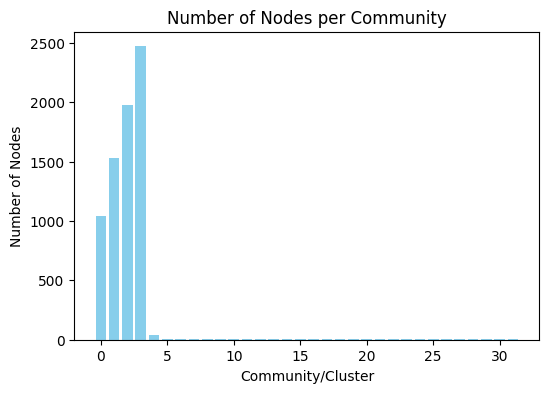

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(community_counts.keys(), community_counts.values(), color='skyblue')
plt.xlabel('Community/Cluster')
plt.ylabel('Number of Nodes')
plt.title('Number of Nodes per Community')
plt.show()


In [23]:
# Summary stats
num_communities = len(community_counts)
print(f"\nThe graph contains {num_communities} communities.")
print("Smallest community:", min(community_counts.values()))
print("Largest community:", max(community_counts.values()))


The graph contains 32 communities.
Smallest community: 2
Largest community: 2470


In [25]:
import networkx as nx
import community as community_louvain  
from collections import defaultdict

# Compute the best partition
partition = community_louvain.best_partition(G.to_undirected())  # undirected graph needed

# Now group nodes by community
communities = defaultdict(list)
for node, comm in partition.items():
    communities[comm].append(node)

# Print first 5 communities
for comm, nodes in list(communities.items())[:5]:
    print(f"Community {comm}: {nodes[:10]} ...")


Community 0: ['30', '3', '28', '39', '54', '108', '152', '178', '182', '214'] ...
Community 8: ['1412', '407', '706', '959', '3755', '171', '285', '290', '298', '579'] ...
Community 15: ['3352', '1453', '2651', '3892', '4942', '465', '608', '825', '1239', '1259'] ...
Community 3: ['5254', '5543', '7478', '1982', '4037', '4134', '4792', '5697', '6227', '6330'] ...
Community 5: ['1648', '2909', '5323', '15', '1542', '1680', '2364', '2490', '2775', '3092'] ...


Number of communities with nodes: 32


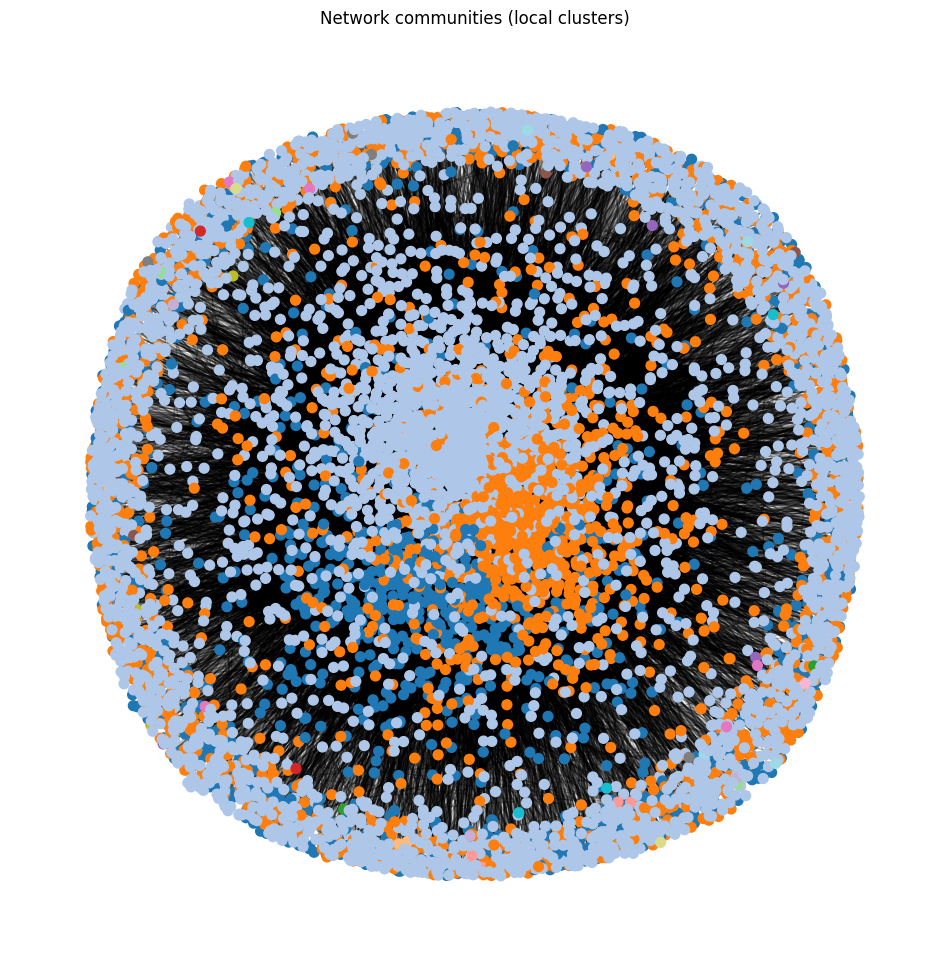

In [215]:
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
from collections import defaultdict
from collections import Counter

# If your graph is directed, convert to undirected
G_undirected = G.to_undirected()

# Detect communities
partition = community_louvain.best_partition(G_undirected)

# Count number of communities
community_counts = Counter(partition.values())
num_actual_communities = len(community_counts)
print(f"Number of communities with nodes: {num_actual_communities}")

# Draw network with community colors
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_undirected, k=0.3, iterations=50)
colors = [partition[node] for node in G_undirected.nodes()]

nx.draw_networkx_nodes(G_undirected, pos, node_size=50, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_undirected, pos, alpha=0.3)
plt.axis('off')
plt.title("Network communities (local clusters)")
plt.show()

# Global Network Statistics (Density , Diameter)

In [26]:
# Global Network Stats
density = nx.density(G)

largest_cc = max(nx.weakly_connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc)

try:
    diameter = nx.diameter(G_lcc.to_undirected())
except:
    diameter = "Not computable"

print("\n--- Global Network Stats ---")
print("Density:", density)
print("Diameter:", diameter)


--- Global Network Stats ---
Density: 0.0020485375110809584
Diameter: 7


Having few connections overall (sparse) does not mean nodes are far apart. If there are hub nodes connecting many others, the network can still be compact.

# Centralities 

It tells which nodes are important in a graph , but important can mean different things:

# Betweenness centrality 

It measures how often a node appears on the shortest paths between other nodes in the network.
- A high betweenness value means the node is a bridge or broker connecting different parts of the network.
- Nodes with high betweenness are critical for information flow—if they are removed, the network may become disconnected or communication may slow down.

In [28]:
bet_centrality = nx.betweenness_centrality(G)
top_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:10] #a normalized score
print("Top 10 users by betweenness centrality")

df_top_bet = pd.DataFrame(top_bet, columns=["Node", "Betweenness"])
print(df_top_bet)

Top 10 users by betweenness centrality
   Node  Betweenness
0  2565     0.017654
1  1549     0.016564
2    15     0.011563
3    72     0.008012
4   737     0.006135
5  1166     0.005803
6  5079     0.005438
7  2328     0.005202
8  2237     0.004715
9    28     0.004564


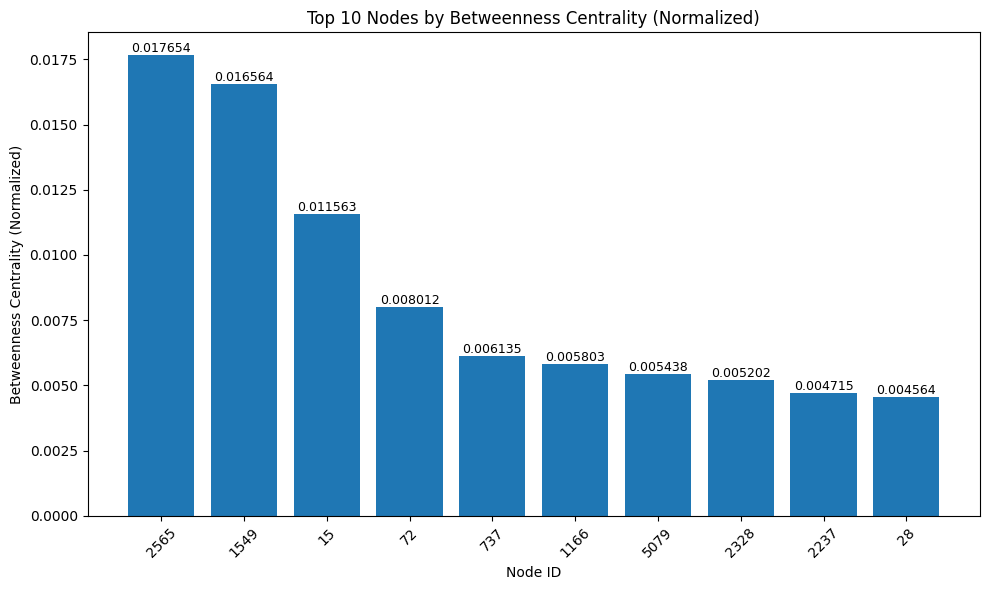

In [220]:
# Compute normalized betweenness centrality (default)
bet_centrality_norm = nx.betweenness_centrality(G, normalized=True)

# Sort and get top 10 nodes
top_bet_norm = sorted(bet_centrality_norm.items(), key=lambda x: x[1], reverse=True)[:10]

# Separate node IDs and scores
nodes = [x[0] for x in top_bet_norm]
scores = [x[1] for x in top_bet_norm]

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(nodes, scores)

# Add normalized value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.6f}",   # more precision (normalized numbers are small)
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Node ID")
plt.ylabel("Betweenness Centrality (Normalized)")
plt.title("Top 10 Nodes by Betweenness Centrality (Normalized)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


How to interpret the actual values
- Betweenness is normalized between 0 and 1.
- Values around 0.01–0.02 are very high for a large network like WikiVote.
- Values near 0 mean the node is not on many shortest paths.

So this ranking identifies users whose votes connect otherwise isolated parts of the Wikipedia voting community.

In [29]:
import networkx as nx
import pandas as pd

# Compute UN-NORMALIZED betweenness centrality
bet_centrality = nx.betweenness_centrality(G, normalized=False)

# Top 10 nodes by raw betweenness score
top_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 users by UN-normalized betweenness centrality")

df_top_bet = pd.DataFrame(top_bet, columns=["Node", "Betweenness"])
print(df_top_bet)


Top 10 users by UN-normalized betweenness centrality
   Node    Betweenness
0  2565  893346.349241
1  1549  838174.431166
2    15  585088.676178
3    72  405413.298405
4   737  310442.395330
5  1166  293619.790241
6  5079  275184.702131
7  2328  263248.568035
8  2237  238579.114227
9    28  230946.610978


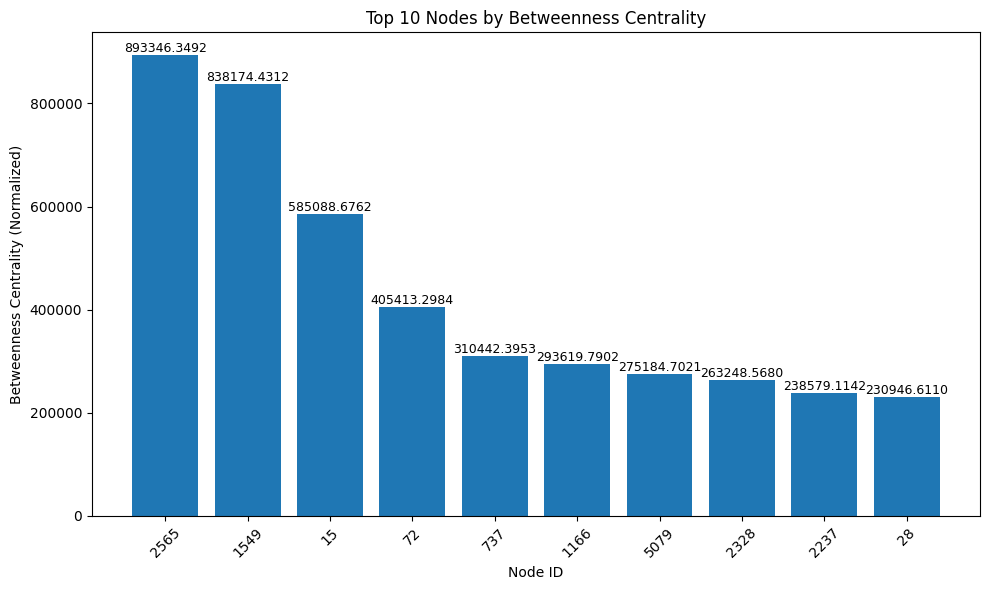

In [221]:
# Sort and get top 10 nodes
top_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

# Separate node IDs and scores
nodes = [x[0] for x in top_bet]
scores = [x[1] for x in top_bet]

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(nodes, scores)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",   # format to 4 decimals (change if you want)
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Node ID")
plt.ylabel("Betweenness Centrality (Normalized)")
plt.title("Top 10 Nodes by Betweenness Centrality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Note : High stress nodes may or may not have high betweenness:
- Stress counts all shortest paths through the node.
- Betweenness counts the fraction of shortest paths between all other nodes.

# Closeness Centrality

It measures how close a node is to all other nodes in the network.
- Can be calculated as the inverse of the average shortest path length from the node to all other nodes.
- Higher closeness value → node can reach all other nodes more quickly, meaning it is central in terms of distance.

In [30]:
closeness = nx.closeness_centrality(G)
top_close = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 users by closeness centrality")
top_close

df_top_clo= pd.DataFrame(top_close, columns=["Node", "Closeness"])
print(df_top_clo)

Top 10 users by closeness centrality
   Node  Closeness
0  4037   0.296483
1    15   0.291490
2  2398   0.290922
3  1549   0.281927
4  2535   0.279901
5  3089   0.278048
6   762   0.278007
7  5412   0.277818
8  2565   0.277614
9  5254   0.276567


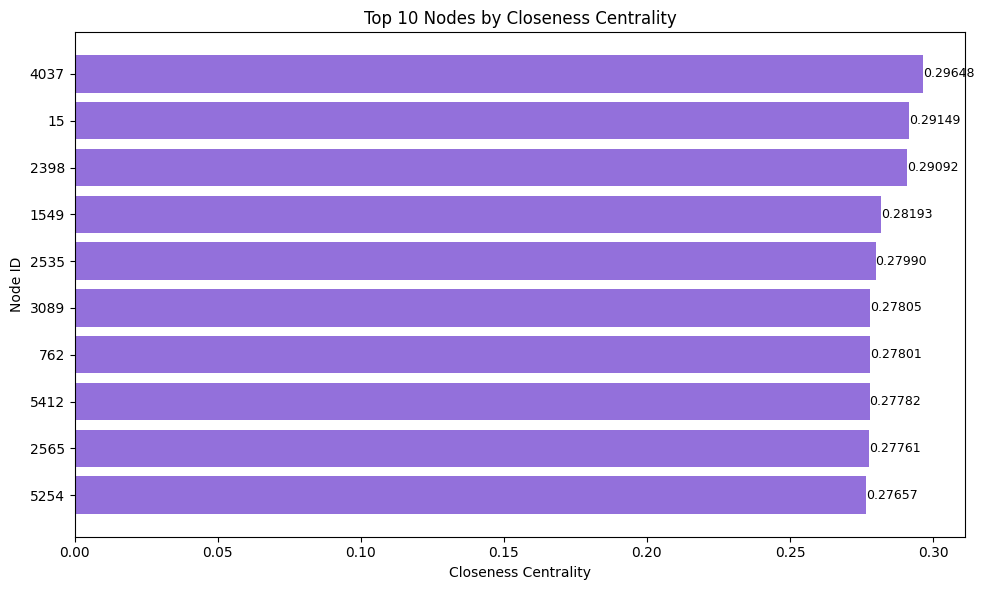

In [225]:
plt.figure(figsize=(10,6))

bars = plt.barh(df_top_clo["Node"].astype(str), df_top_clo["Closeness"], color='mediumpurple')

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                       
        bar.get_y() + bar.get_height()/2,  
        f"{width:.5f}",              
        va='center',
        ha='left',
        fontsize=9
    )

plt.xlabel("Closeness Centrality")
plt.ylabel("Node ID")
plt.title("Top 10 Nodes by Closeness Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# PageRank

A network centrality that measures the importance of a node based on its connections where a node is important if it is connected to other important nodes.
- It's values are normalized scores that typically sum to 1 across all nodes in the network.

In [31]:
pagerank = nx.pagerank(G, alpha=0.85)
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 users by PageRank")

df_pr= pd.DataFrame(top_close, columns=["Node", "PageRank"])
print(df_pr)

Top 10 users by PageRank
   Node  PageRank
0  4037  0.296483
1    15  0.291490
2  2398  0.290922
3  1549  0.281927
4  2535  0.279901
5  3089  0.278048
6   762  0.278007
7  5412  0.277818
8  2565  0.277614
9  5254  0.276567


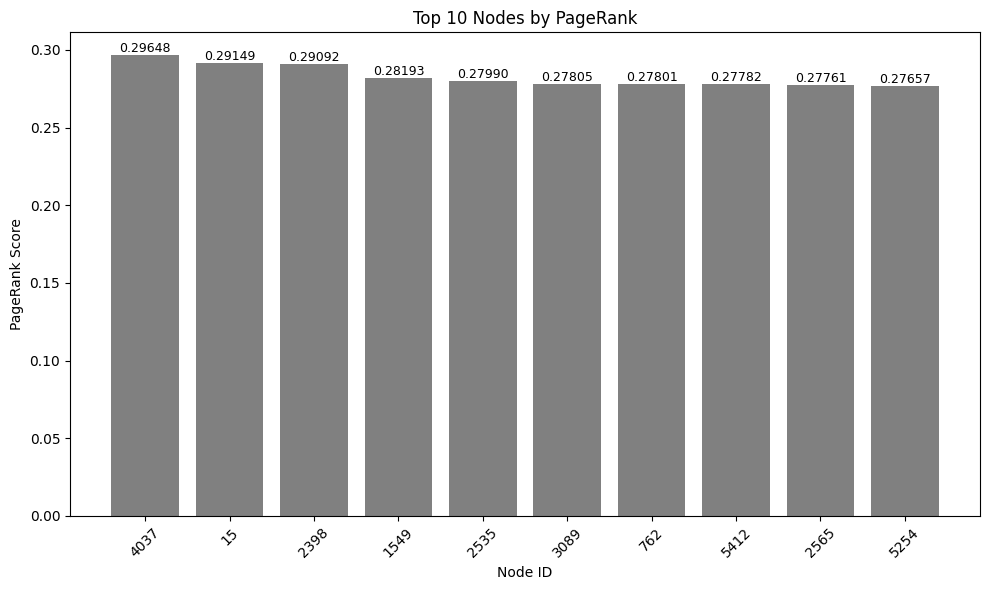

In [230]:
plt.figure(figsize=(10,6))
bars = plt.bar(df_pr["Node"], df_pr["PageRank"], color='gray')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # center of bar
        height,                            # top of bar
        f"{height:.5f}",                   # value format
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Node ID")
plt.ylabel("PageRank Score")
plt.title("Top 10 Nodes by PageRank")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Nodes like 4037 and 15 → top in both closeness and PageRank → they are influential and central hubs.

Nodes like 6634 and 2625 → high PageRank but not top in stress → important by association, not by shortest paths.

# HITS algorithm

An algorithm that assigns two scores to each node:
- Authority score → How valuable or credible a node is, based on the incoming links from good hubs.
- Hub score → How good a node is at linking to authoritative nodes.

In [32]:
hubs, authorities = nx.hits(G)
top_auth = sorted(authorities.items(), key=lambda x: x[1], reverse=True)[:10]
top_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:10]

In [33]:
print("Top 10 authorities")
df_auth= pd.DataFrame(top_auth, columns=["Node", "Authorities"])
print(df_auth)

Top 10 authorities
   Node  Authorities
0  2398     0.002580
1  4037     0.002573
2  3352     0.002328
3  1549     0.002304
4   762     0.002256
5  3089     0.002253
6  1297     0.002250
7  2565     0.002224
8    15     0.002202
9  2625     0.002198


In [34]:
print("Top 10 Hubs")
df_hubs= pd.DataFrame(top_hubs, columns=["Node", "Hubs"])
print(df_hubs)

Top 10 Hubs
   Node      Hubs
0  2565  0.007940
1   766  0.007574
2  2688  0.006440
3   457  0.006417
4  1166  0.006011
5  1549  0.005721
6    11  0.004921
7  1151  0.004572
8  1374  0.004468
9  1133  0.003919


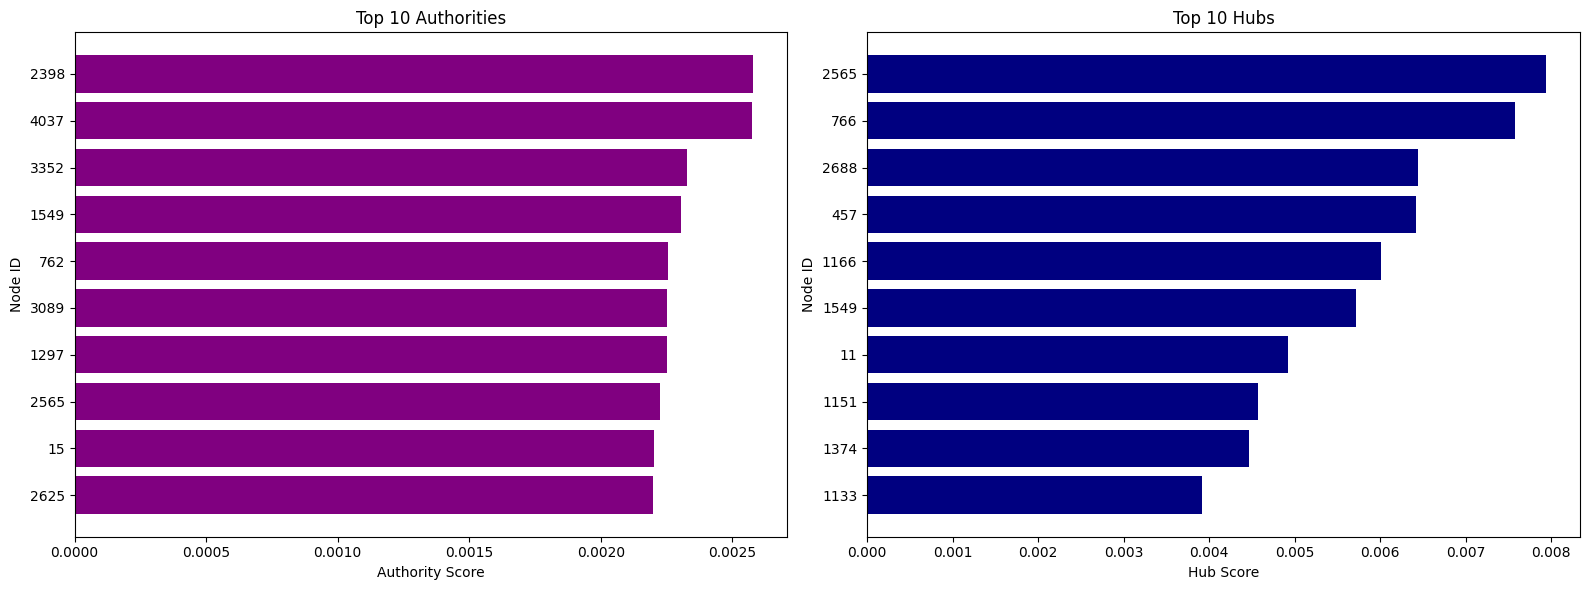

In [234]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Authorities
ax[0].barh(df_auth["Node"].astype(str), df_auth["Authorities"], color='purple')
ax[0].invert_yaxis()
ax[0].set_title("Top 10 Authorities")
ax[0].set_xlabel("Authority Score")
ax[0].set_ylabel("Node ID")

# Hubs
ax[1].barh(df_hubs["Node"].astype(str), df_hubs["Hubs"], color ='navy')
ax[1].invert_yaxis()
ax[1].set_title("Top 10 Hubs")
ax[1].set_xlabel("Hub Score")
ax[1].set_ylabel("Node ID")

plt.tight_layout()
plt.show()


High authority ≠ high stress or betweenness: A node can be very authoritative even if it’s not a bridge.

Example: '2398' is top authority but not top stress.

Interpretation

Hub vs Authority:
- Hub → a node that points to important nodes (good distributor).
- Authority → a node that is pointed to by good hubs (good source of information).

In that network:
- Nodes like 2565, 1549 → both strong hubs and authorities → key connectors and influential nodes.
- Other nodes may be good hubs without being top authorities, meaning they guide or connect the network rather than being the main sources.

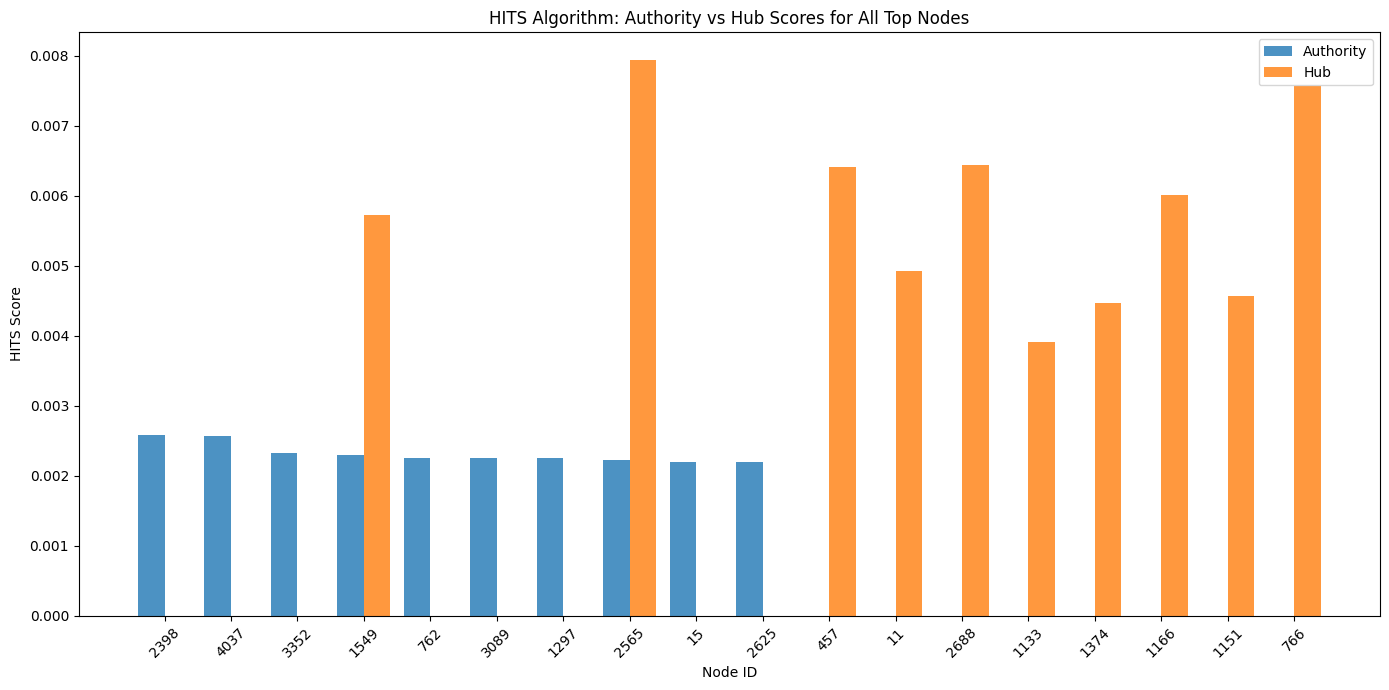

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert lists to DataFrames
df_auth = pd.DataFrame(top_auth, columns=["Node", "Authority"])
df_hubs = pd.DataFrame(top_hubs, columns=["Node", "Hub"])

# Merge using outer join (keeps all nodes)
df = pd.merge(df_auth, df_hubs, on="Node", how="outer")

# Fill missing values with zeros (nodes that appear only in one list)
df = df.fillna(0)

# Sort by Authority or Hub (optional)
df = df.sort_values(by="Authority", ascending=False)

# Prepare x positions
x = np.arange(len(df["Node"]))
width = 0.4

plt.figure(figsize=(14,7))

# Bars for Authority & Hub
plt.bar(x - width/2, df["Authority"], width, label="Authority", alpha=0.8)
plt.bar(x + width/2, df["Hub"], width, label="Hub", alpha=0.8)

# Axis labels
plt.xticks(x, df["Node"].astype(str), rotation=45)
plt.xlabel("Node ID")
plt.ylabel("HITS Score")
plt.title("HITS Algorithm: Authority vs Hub Scores for All Top Nodes")
plt.legend()
plt.tight_layout()
plt.show()


# Eigenvector centrality

(EC) measures a node’s influence based on the influence of its neighbors , 
- A node connected to many highly connected nodes gets a higher EC.
- A node connected to peripheral nodes gets a lower EC, even if it has the same number of edges.

In [35]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Compute Eigenvector Centrality
try:
    eig_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)

    # Convert to DataFrame for readability
    df_eig = pd.DataFrame(eig_centrality.items(), columns=["Node", "EigenvectorCentrality"])
    df_eig = df_eig.sort_values(by="EigenvectorCentrality", ascending=False)

    print("=== Top 10 Nodes by Eigenvector Centrality ===")
    print(df_eig.head(10))

except nx.NetworkXException as e:
    print("Eigenvector centrality did not converge:", e)


=== Top 10 Nodes by Eigenvector Centrality ===
      Node  EigenvectorCentrality
905   2398               0.117198
326   4037               0.108955
409     15               0.098179
1141  4191               0.095690
711   2625               0.095526
286   1549               0.095032
666   2328               0.094837
1005  3089               0.093107
1028  5412               0.090508
626   2066               0.090484


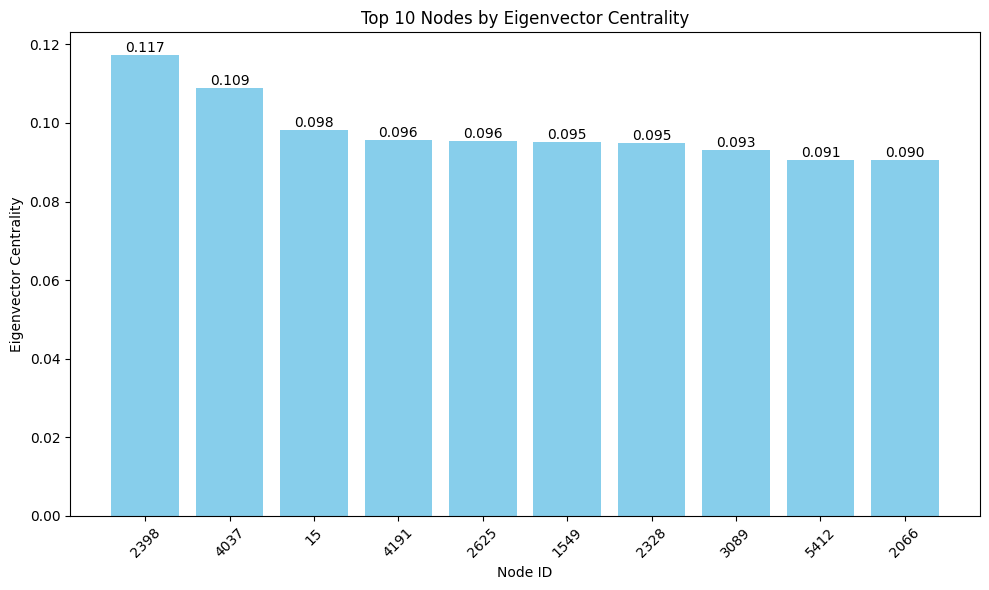

In [238]:
import matplotlib.pyplot as plt

# Select top 10 nodes
df_top_eig = df_eig.head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(df_top_eig["Node"].astype(str), df_top_eig["EigenvectorCentrality"], color='skyblue')

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha='center', va='bottom', fontsize=10)

plt.xlabel("Node ID")
plt.ylabel("Eigenvector Centrality")
plt.title("Top 10 Nodes by Eigenvector Centrality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Harmonic centrality

It measures how “close” a node is to all other nodes in the network, in a way that works even if the network is disconnected.

- High harmonic centrality → node is well-connected and can reach many others quickly.
- Low harmonic centrality → node is peripheral or poorly connected.

In [36]:

harmonic = nx.harmonic_centrality(G)  # remove normalized=True

# For directed graph with n nodes: max possible = n-1
n = G.number_of_nodes()
harmonic_norm = {k: v/(n-1) for k, v in harmonic.items()}

# 2. Convert to DataFrame
harmonic_df = pd.DataFrame.from_dict(harmonic, orient="index", columns=["HarmonicCentrality"])
harmonic_df.index.name = "Node"
harmonic_df.reset_index(inplace=True)
harmonic_df = harmonic_df.sort_values("HarmonicCentrality", ascending=False)

harmonic_df.head(10)

,Node,HarmonicCentrality
609,4037,2382.859524
4328,15,2320.326190
3010,2398,2310.626190
613,1549,2215.776190
3554,1297,2209.584524
5989,762,2200.542857
361,2625,2197.051190
1662,2535,2194.309524
3002,2565,2193.876190
5080,3089,2190.776190


harmonic centrality is usually much larger than degree because it aggregates connectivity to all nodes, not just direct connections.
    
To compare across networks or with other metrics, it’s common to normalize harmonic centrality.

In [37]:
harmonic_norm = {k: v/(n-1) for k, v in harmonic.items()}

harmonic_df = pd.DataFrame.from_dict(harmonic_norm, orient="index", columns=["HarmonicCentrality"])
harmonic_df.index.name = "Node"
harmonic_df.reset_index(inplace=True)
harmonic_df = harmonic_df.sort_values("HarmonicCentrality", ascending=False)

harmonic_df.head(10)

,Node,HarmonicCentrality
609,4037,0.334954
4328,15,0.326163
3010,2398,0.324800
613,1549,0.311467
3554,1297,0.310597
5989,762,0.309326
361,2625,0.308835
1662,2535,0.308449
3002,2565,0.308389
5080,3089,0.307953


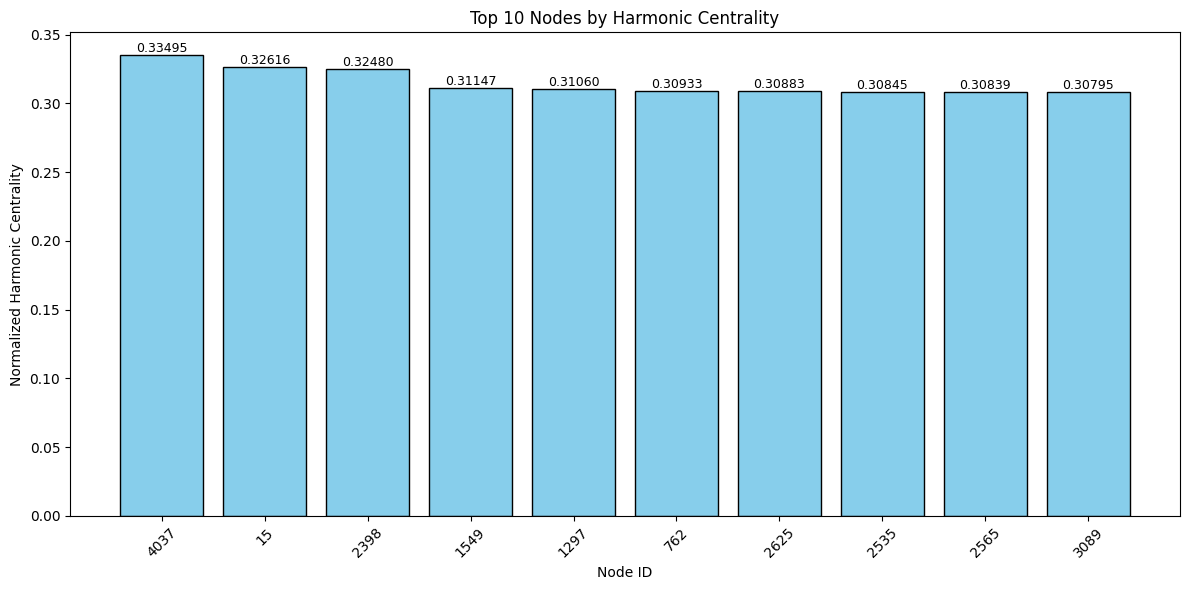

In [241]:
top10 = harmonic_df.head(10)

plt.figure(figsize=(12,6))
bars = plt.bar(
    top10["Node"].astype(str),
    top10["HarmonicCentrality"],
    color='skyblue',
    edgecolor='black'
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # center of bar
        height,                            # vertical position
        f"{height:.5f}",                   # label format
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Node ID")
plt.ylabel("Normalized Harmonic Centrality")
plt.title("Top 10 Nodes by Harmonic Centrality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The nodes can reach about 30% of the network efficiently

# Stress Centrality 

It measure how many shortest paths pass through a node

- High stress → node lies on many shortest paths → acts as a critical connector.

Stress is similar to betweenness centrality, but it counts paths without normalization, Betweenness centrality is stress divided by the total number of shortest paths.

In [38]:
import networkx as nx

def stress_centrality(G):
    stress = dict.fromkeys(G.nodes(), 0)
    for s in G.nodes():
        paths = nx.single_source_shortest_path(G, s)
        for t, path in paths.items():
            # count only inner nodes of paths
            for v in path[1:-1]:
                stress[v] += 1
    return stress

# Compute stress centrality
stress = stress_centrality(G)

# Get top 10 nodes by stress centrality
top_stress = sorted(stress.items(), key=lambda x: x[1], reverse=True)[:10]
top_stress_nodes = [x[0] for x in top_stress]

print("Top 10 nodes by stress centrality:")
df_stress= pd.DataFrame(top_stress, columns=["Node", "Stress"])
print(df_stress)

Top 10 nodes by stress centrality:
   Node   Stress
0    15  1026623
1  2565   882104
2  1549   821648
3   737   637985
4  1166   508952
5    72   479799
6     8   456033
7    28   292810
8   825   291476
9   993   287097


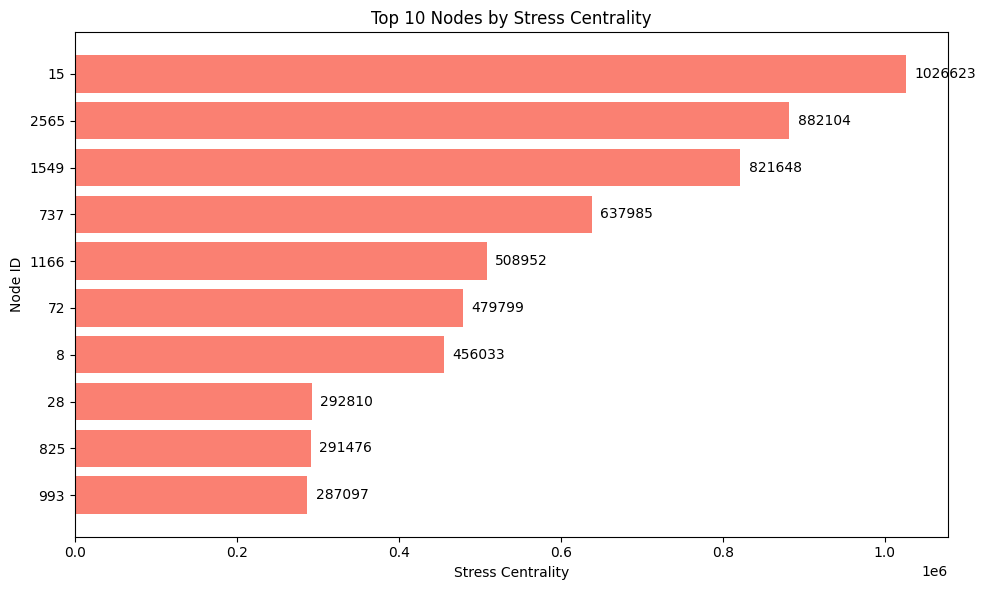

In [245]:
plt.figure(figsize=(10,6))
bars = plt.barh(df_stress["Node"], df_stress["Stress"], color='salmon')

# Add values next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(df_stress["Stress"])*0.01, bar.get_y() + bar.get_height()/2, f"{width}", va='center', fontsize=10)

plt.xlabel("Stress Centrality")
plt.ylabel("Node ID")
plt.title("Top 10 Nodes by Stress Centrality")
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()


In [39]:
max_stress = sum([len(nx.single_source_shortest_path(G, s)) - 1 for s in G.nodes()])
df_stress["StressNormalized"] = df_stress["Stress"] / max_stress

In [40]:
df_stress_sorted = df_stress.sort_values(by="StressNormalized", ascending=False)
print(df_stress_sorted[["Node", "StressNormalized"]].head(10))

   Node  StressNormalized
0    15          0.085940
1  2565          0.073842
2  1549          0.068781
3   737          0.053406
4  1166          0.042605
5    72          0.040165
6     8          0.038175
7    28          0.024511
8   825          0.024400
9   993          0.024033


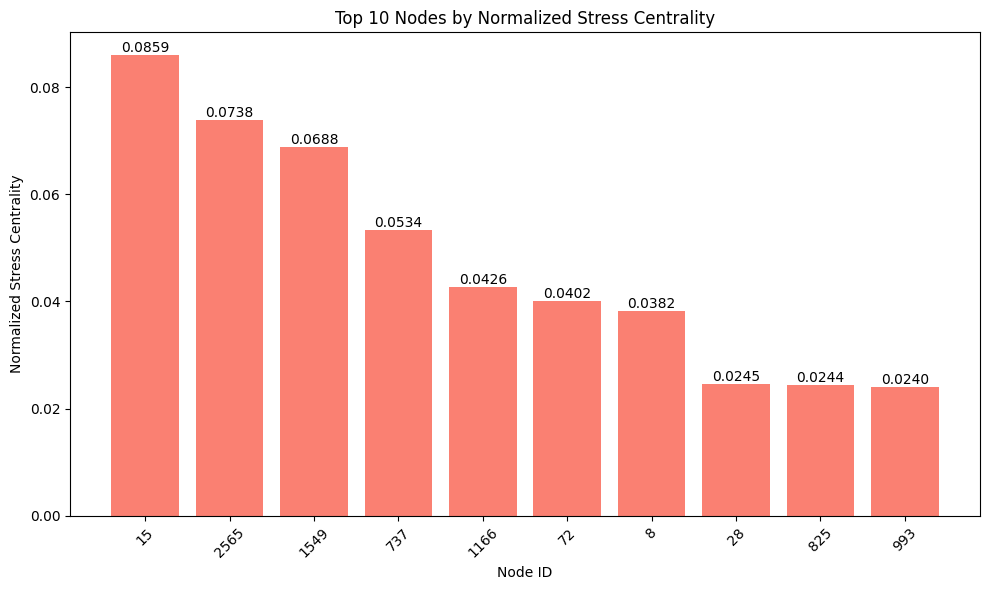

In [248]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
bars = plt.bar(df_stress_sorted["Node"].astype(str).head(10), df_stress_sorted["StressNormalized"].head(10), color='salmon')

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.4f}", ha='center', va='bottom', fontsize=10)

plt.xlabel("Node ID")
plt.ylabel("Normalized Stress Centrality")
plt.title("Top 10 Nodes by Normalized Stress Centrality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Centrality Measures Combined

In [45]:
# Create a DataFrame with all centrality measures
centrality_data = []

for node in G.nodes():
    centrality_data.append({
        "Node": node,
        "In-Degree": in_degrees[node],
        "Out-Degree": out_degrees[node],
        "Betweenness": bet_centrality[node],
        "Closeness": closeness[node],
        "PageRank": pagerank[node],
        "Hub": hubs[node],
        "Authority": authorities[node]
    })

df_centrality = pd.DataFrame(centrality_data)

# Sort by Betweenness and show top 10 nodes
top_nodes = df_centrality.sort_values(by="Betweenness", ascending=False).head(10)

# Display
pd.set_option("display.float_format", "{:.3f}".format)  # nicer formatting
top_nodes


,Node,In-Degree,Out-Degree,Betweenness,Closeness,PageRank,Hub,Authority
699,2565,274,893,893346.349,0.278,0.002,0.008,0.002
286,1549,245,587,838174.431,0.282,0.001,0.006,0.002
409,15,361,50,585088.676,0.291,0.004,0.000,0.002
410,72,154,164,405413.298,0.261,0.001,0.001,0.001
902,737,231,232,310442.395,0.276,0.002,0.002,0.002
1052,1166,144,599,293619.790,0.257,0.001,0.006,0.001
1146,5079,165,271,275184.702,0.263,0.001,0.003,0.001
666,2328,266,215,263248.568,0.270,0.002,0.002,0.002
656,2237,181,241,238579.114,0.254,0.003,0.003,0.001
7,28,122,133,230946.611,0.227,0.002,0.000,0.000


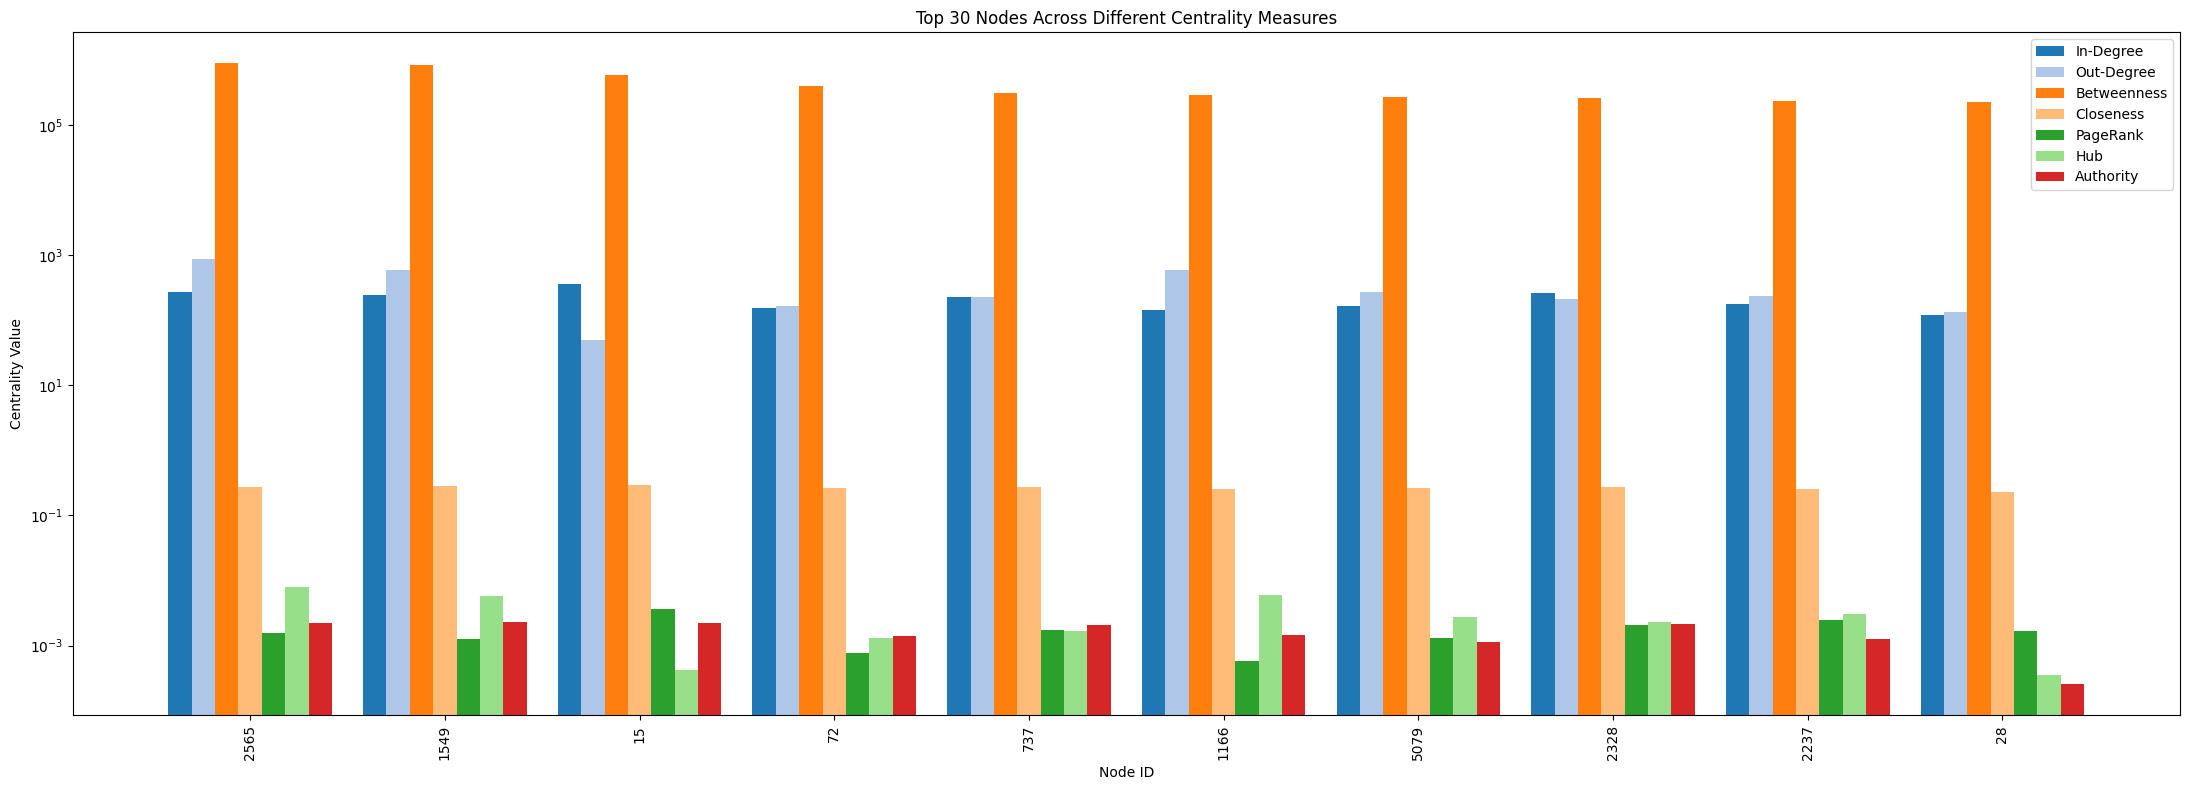

In [251]:
import matplotlib.pyplot as plt
import numpy as np

# Select metrics to plot
metrics = ["In-Degree", "Out-Degree", "Betweenness", "Closeness", "PageRank", "Hub", "Authority"]

# Prepare positions
x = np.arange(len(top_nodes))  # one position per node
width = 0.12  # width of each bar
colors = plt.cm.tab20.colors  # color palette

plt.figure(figsize=(22,8))

# Plot each metric as a separate bar
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, top_nodes[metric], width, label=metric, color=colors[i % len(colors)])

# Labels and formatting
plt.xticks(x + width*3, top_nodes["Node"].astype(str), rotation=90)  # center tick labels
plt.xlabel("Node ID")
plt.ylabel("Centrality Value")
plt.yscale('log')
plt.title("Top 30 Nodes Across Different Centrality Measures")
plt.legend()
plt.tight_layout()
plt.show()


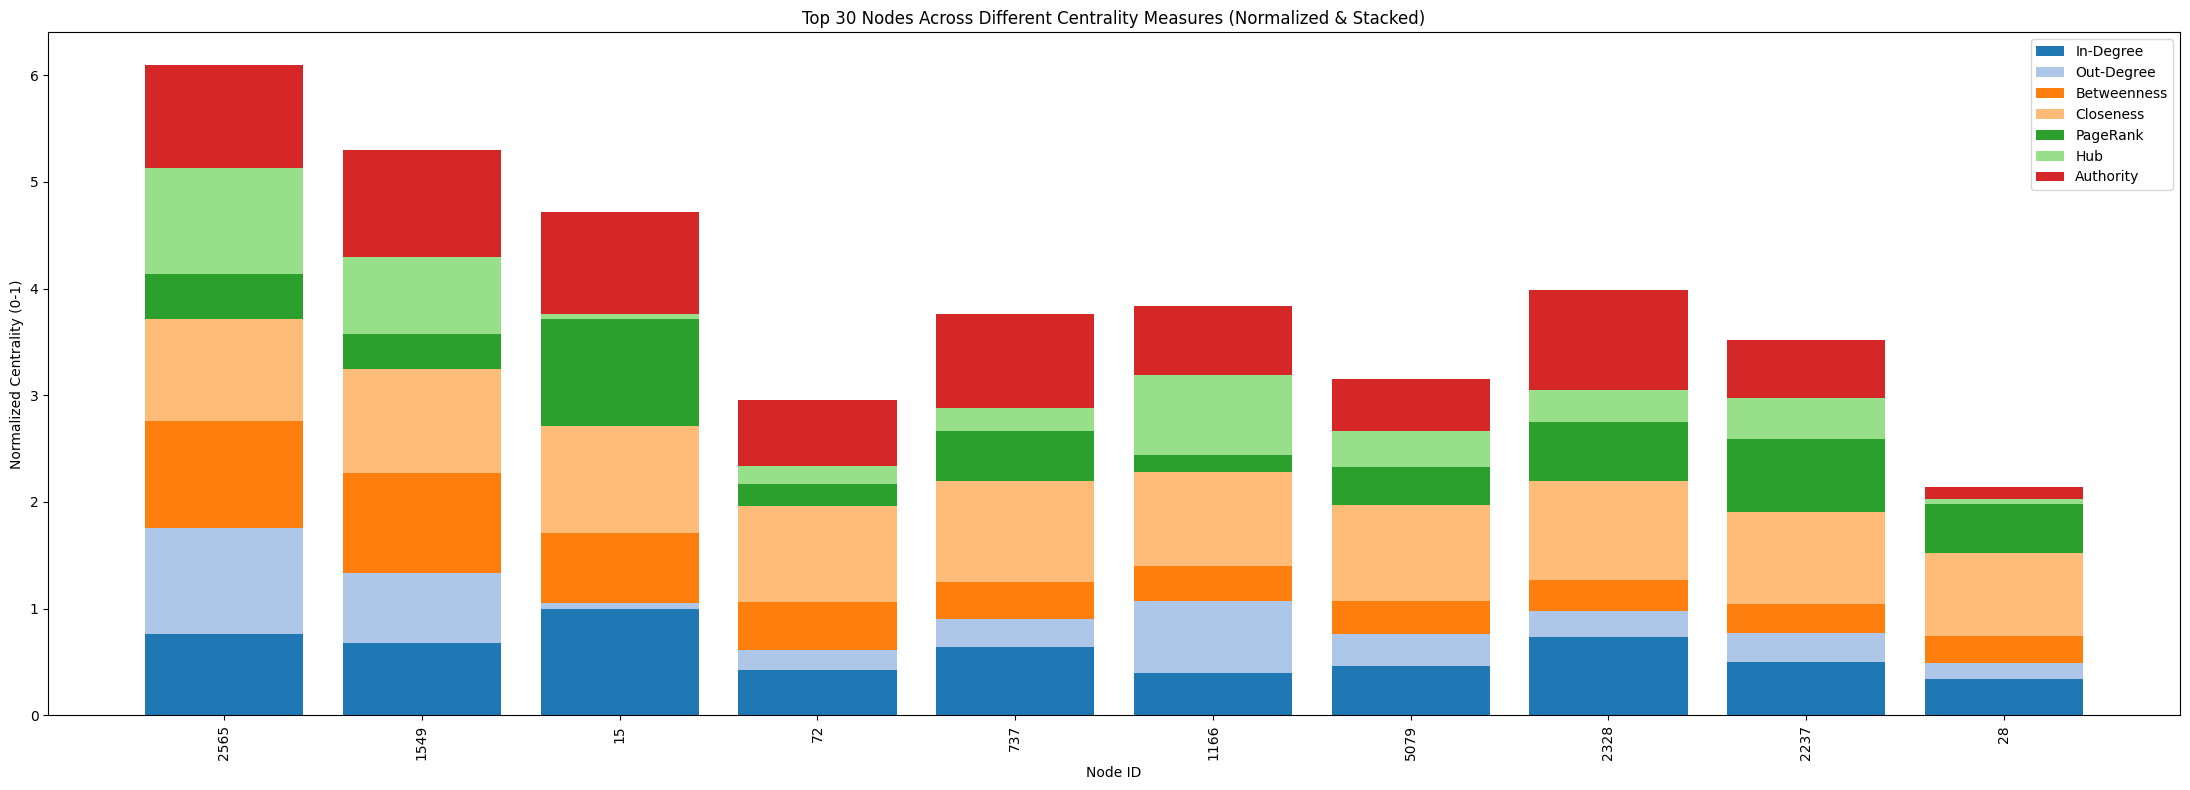

In [252]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics = ["In-Degree", "Out-Degree", "Betweenness", "Closeness", "PageRank", "Hub", "Authority"]

x = np.arange(len(top_nodes))  # positions for nodes
colors = plt.cm.tab20.colors  # color palette

# Normalize each metric (divide by max of that metric)
top_nodes_norm = top_nodes.copy()
for metric in metrics:
    top_nodes_norm[metric] = top_nodes[metric] / top_nodes[metric].max()

plt.figure(figsize=(22,8))
bottom = np.zeros(len(top_nodes))

# Plot stacked bars using normalized values
for i, metric in enumerate(metrics):
    plt.bar(x, top_nodes_norm[metric], bottom=bottom, label=metric, color=colors[i % len(colors)])
    bottom += top_nodes_norm[metric]  # update bottom for stacking

# Labels and formatting
plt.xticks(x, top_nodes["Node"].astype(str), rotation=90)
plt.xlabel("Node ID")
plt.ylabel("Normalized Centrality (0-1)")
plt.title("Top 30 Nodes Across Different Centrality Measures (Normalized & Stacked)")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Micro Systems\AppData\Local\Temp\ipykernel_12424\1570956720.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.         0.02479339 0.99586777 1.         0.50413223]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_norm.iloc[:, 1:] = scaler.fit_transform(df_norm.iloc[:, 1:])
C:\Users\Micro Systems\AppData\Local\Temp\ipykernel_12424\1570956720.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01831502 0.         1.         0.12087912 0.5018315 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_norm.iloc[:, 1:] = scaler.fit_transform(df_norm.iloc[:, 1:])


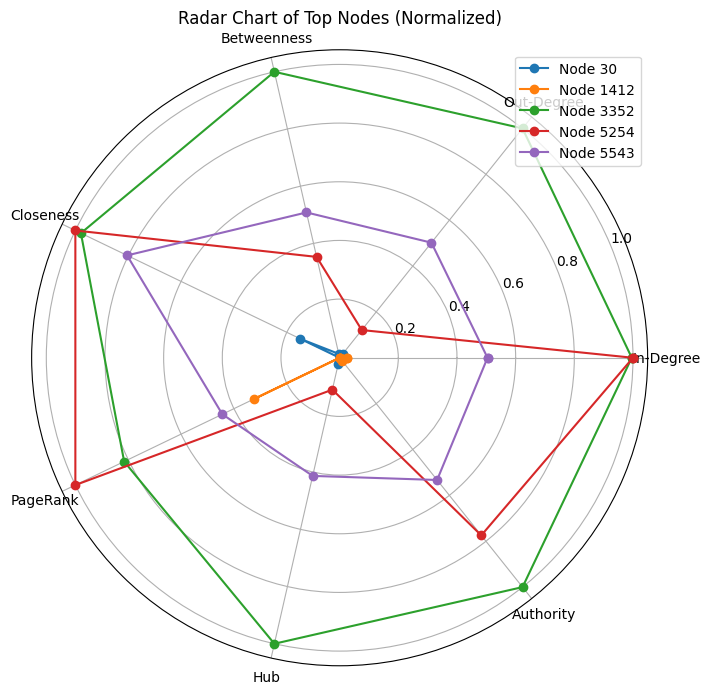

In [279]:
from math import pi
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Pick top 5 nodes
top_nodes = df_centrality.head(5)
categories = list(df_centrality.columns[1:])  # all metrics
N = len(categories)

# Normalize metrics for radar chart
scaler = MinMaxScaler()
df_norm = top_nodes.copy()
df_norm.iloc[:, 1:] = scaler.fit_transform(df_norm.iloc[:, 1:])

# Angles for radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8,8))
for i, row in df_norm.iterrows():
    values = row[1:].tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Node {row['Node']}", marker='o')

plt.xticks(angles[:-1], categories)
plt.title("Radar Chart of Top Nodes (Normalized)")
plt.legend(loc='upper right')
plt.show()


| Node ID | In-Degree | Out-Degree | Closeness | PageRank  | Hub       | Authority | Interpretation                                                                  |
| ------- | --------- | ---------- | --------- | --------- | --------- | --------- | --------------------------------------------------------------------------------|
| 2565    | Medium    | Very High  | Low       | Low       | Very High | Very High | Strong broadcaster, connects to important nodes,but not strongly central overall|
| 1549    | Medium    | High       | Medium    | Low       | High      | High      | Influential in spreading information, more balanced than 2565                   |
| 15      | Very High | Low        | Very High | Very High | Low       | Medium    | Major authority node, central and highly important                              |
| 72      | Very Low  | Very Low   | Very Low  | Very Low  | Very Low  | Very Low  | Peripheral node, minimal influence                                              |
| 737     | Medium    | Medium     | Medium    | Low       | Low       | Medium    | Moderately connected, somewhat central but not highly influential               |


# Clustering Coefficient

The clustering coefficient measures how tightly connected a node’s neighbors are , The value is always between 0 and 1.
- 0: no clustering (neighbors are not connected)
- 1: fully connected clusters (all neighbors connected)

In [254]:
import pandas as pd
import networkx as nx

# Compute clustering coefficient (convert to undirected for local clustering)
clustering_coeffs = nx.clustering(G.to_undirected())

# Convert to DataFrame for better readability
clustering_df = pd.DataFrame(list(clustering_coeffs.items()), columns=["Node", "Clustering Coefficient"])

# Display first 10 nodes
clustering_df.head(10)


,Node,Clustering Coefficient
0,30,0.151
1,1412,0.049
2,3352,0.113
3,5254,0.085
4,5543,0.143
5,7478,0.096
6,3,0.220
7,28,0.088
8,39,0.188
9,54,0.262


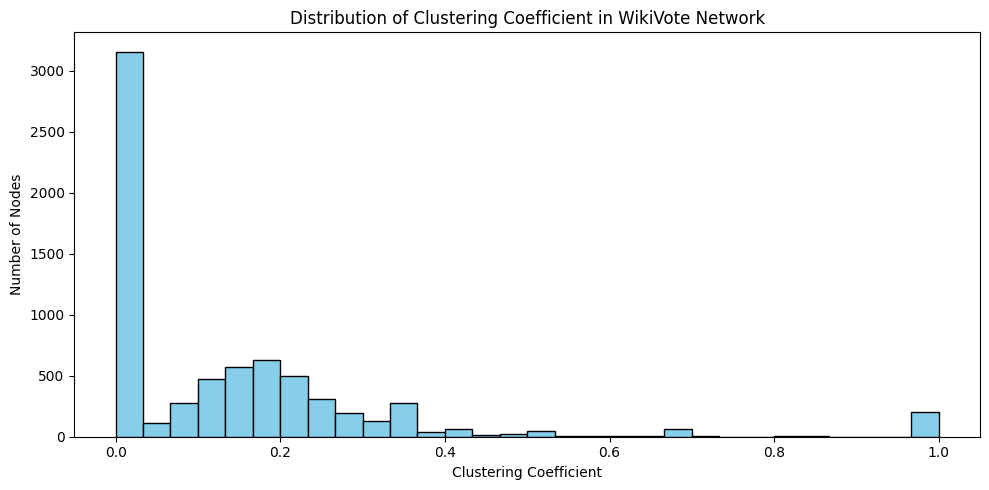

In [255]:
plt.figure(figsize=(10,5))
plt.hist(clustering_df["Clustering Coefficient"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Clustering Coefficient")
plt.ylabel("Number of Nodes")
plt.title("Distribution of Clustering Coefficient in WikiVote Network")
plt.tight_layout()
plt.show()

In [256]:
# Compute average clustering coefficient
average_clustering = np.mean(list(clustering_coeffs.values()))
print("Average clustering coefficient:", round(average_clustering, 3))

Average clustering coefficient: 0.141


# Adjacency matrix

In [257]:
import pandas as pd

# Adjacency matrix as DataFrame
adj_df = nx.to_pandas_adjacency(G)
adj_df

,30,1412,3352,5254,5543,7478,3,28,39,54,...,8262,8264,8265,8266,7637,8270,8272,8273,8150,8274
30,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1412,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3352,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5254,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5543,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8270,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8272,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8273,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8150,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [258]:
# Convert DataFrame to NumPy array
matrix = adj_df.to_numpy()

# Count number of edges (1s) and non-edges (0s)
num_ones = np.sum(matrix == 1)
num_zeros = np.sum(matrix == 0)

print("Number of 1s (edges):", num_ones)
print("Number of 0s (no edge):", num_zeros)


Number of 1s (edges): 103689
Number of 0s (no edge): 50519536


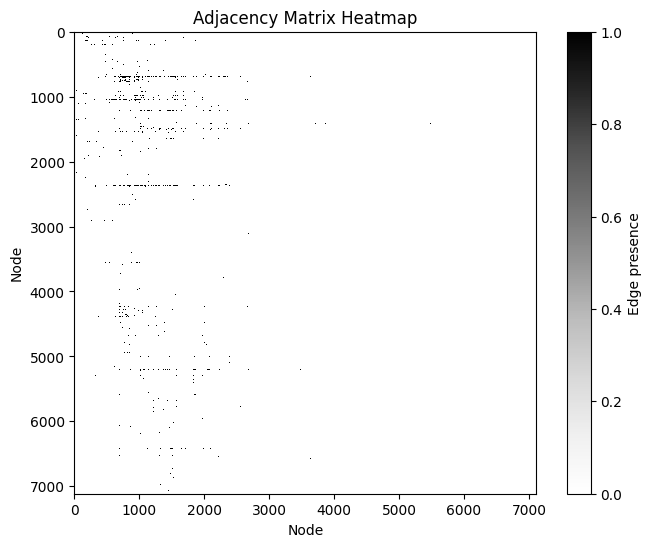

In [259]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(adj_df, cmap='Greys', interpolation='none')
plt.colorbar(label='Edge presence')
plt.xlabel('Node')
plt.ylabel('Node')
plt.title('Adjacency Matrix Heatmap')
plt.show()

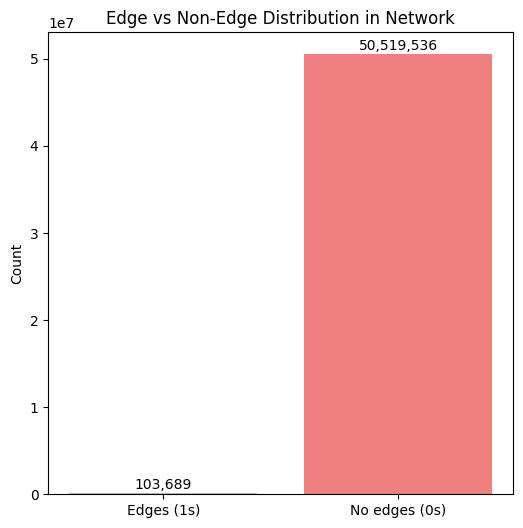

In [260]:
# Data for bar chart
labels = ['Edges (1s)', 'No edges (0s)']
counts = [num_ones, num_zeros]
colors = ['skyblue', 'lightcoral']

# Plot bar chart
plt.figure(figsize=(6,6))
plt.bar(labels, counts, color=colors)
plt.ylabel('Count')
plt.title("Edge vs Non-Edge Distribution in Network")

# Optionally, add values on top of bars
for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, f'{count:,}', ha='center', fontsize=10)

plt.show()

# Edge List

In [275]:
import pandas as pd

edge_df = pd.DataFrame(G.edges(), columns=['Source', 'Target'])
edge_df.head()

,Source,Target
0,30,1412
1,30,3352
2,30,5254
3,30,5543
4,30,7478


In [277]:
# Print only the first 10 edges
for i, edge in enumerate(G.edges()):
    if i == 10:  # stop after 10
        break
    print(edge)

('30', '1412')
('30', '3352')
('30', '5254')
('30', '5543')
('30', '7478')
('3352', '72')
('3352', '285')
('3352', '417')
('3352', '465')
('3352', '608')


# Degree Distribution

A summary showing how many nodes have each degree value.

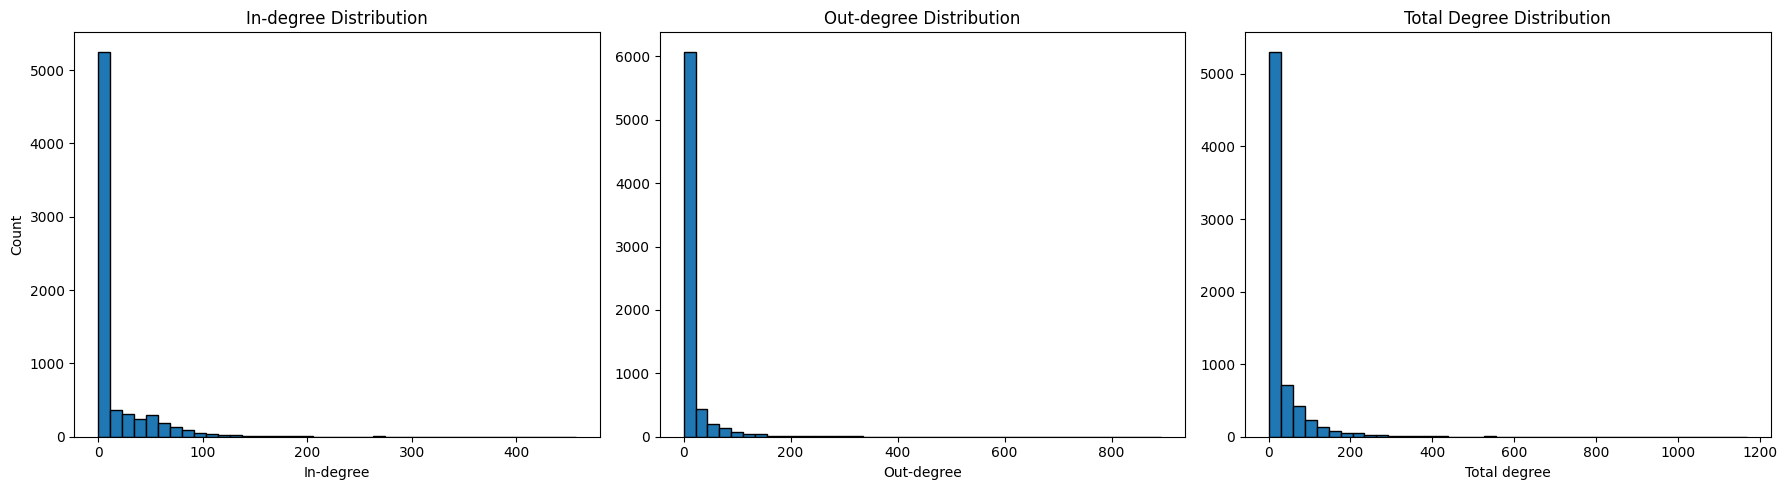

In [264]:
import matplotlib.pyplot as plt

in_deg = [G.in_degree(n) for n in G.nodes()]
out_deg = [G.out_degree(n) for n in G.nodes()]
total_deg = [G.in_degree(n) + G.out_degree(n) for n in G.nodes()]

plt.figure(figsize=(18, 5))

# In-degree
plt.subplot(1, 3, 1)
plt.hist(in_deg, bins=40, edgecolor='black')
plt.title("In-degree Distribution")
plt.xlabel("In-degree")
plt.ylabel("Count")

# Out-degree
plt.subplot(1, 3, 2)
plt.hist(out_deg, bins=40, edgecolor='black')
plt.title("Out-degree Distribution")
plt.xlabel("Out-degree")

# Total degree
plt.subplot(1, 3, 3)
plt.hist(total_deg, bins=40, edgecolor='black')
plt.title("Total Degree Distribution")
plt.xlabel("Total degree")

plt.tight_layout()
plt.show()


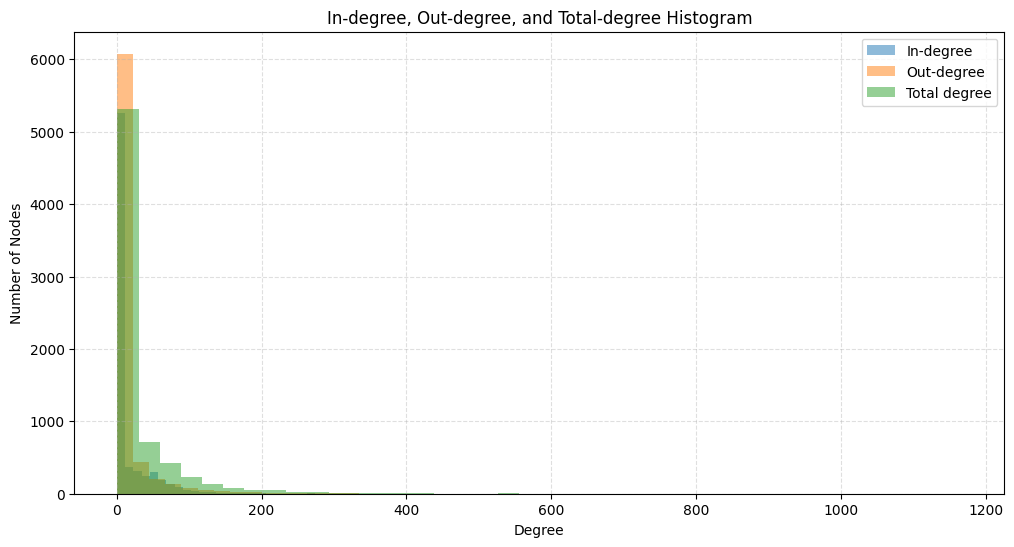

In [265]:
import matplotlib.pyplot as plt

# Compute degrees
in_deg = [G.in_degree(n) for n in G.nodes()]
out_deg = [G.out_degree(n) for n in G.nodes()]
total_deg = [G.in_degree(n) + G.out_degree(n) for n in G.nodes()]

plt.figure(figsize=(12, 6))

plt.hist(in_deg, bins=40, alpha=0.5, label='In-degree')
plt.hist(out_deg, bins=40, alpha=0.5, label='Out-degree')
plt.hist(total_deg, bins=40, alpha=0.5, label='Total degree')

plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.title("In-degree, Out-degree, and Total-degree Histogram")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()


# Path Length 

it tells how many steps it takes to go from one node to another through the edges of the graph.

In [266]:
import networkx as nx
import numpy as np

# Get largest SCC
G_scc = max(nx.strongly_connected_components(G), key=len)
G_largest_scc = G.subgraph(G_scc).copy()

# Compute shortest path lengths
path_length = dict(nx.shortest_path_length(G_largest_scc))

# Nodes list
nodes = list(G_largest_scc.nodes())
n = len(nodes)

# Distance matrix
dist_matrix = np.full((n, n), np.inf)
for i, u in enumerate(nodes):
    for v, d in path_length[u].items():
        dist_matrix[i, nodes.index(v)] = d

print(dist_matrix)


[[0. 2. 2. ... 1. 3. 2.]
 [2. 0. 2. ... 2. 2. 2.]
 [3. 2. 0. ... 3. 3. 3.]
 ...
 [1. 2. 3. ... 0. 3. 2.]
 [3. 3. 3. ... 3. 0. 3.]
 [4. 4. 4. ... 4. 4. 0.]]


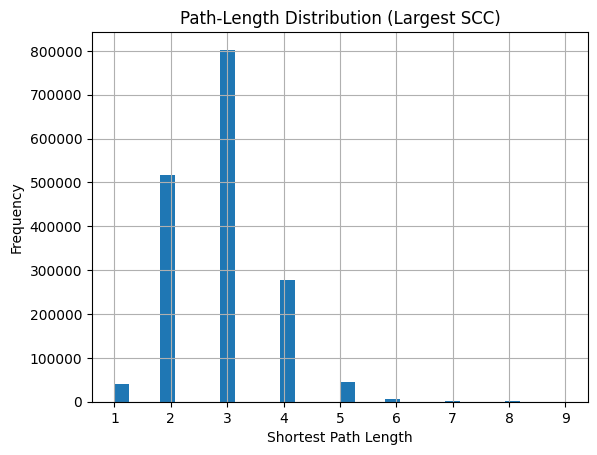

In [267]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- Use largest strongly connected component ---
largest_scc = max(nx.strongly_connected_components(G), key=len)
G_scc = G.subgraph(largest_scc)

# --- Compute all-pairs shortest path lengths ---
path_lengths = []
for source, targets in nx.all_pairs_shortest_path_length(G_scc):
    for target, dist in targets.items():
        if source != target:   # ignore distance to itself
            path_lengths.append(dist)

# --- Convert to numpy array ---
path_lengths = np.array(path_lengths)

# --- Plot histogram ---
plt.hist(path_lengths, bins=30)
plt.xlabel("Shortest Path Length")
plt.ylabel("Frequency")
plt.title("Path-Length Distribution (Largest SCC)")
plt.grid(True)
plt.show()


# Shortest path lengths

The average number of steps along the shortest paths for all possible pairs of nodes in the network.

In [268]:
import networkx as nx
import numpy as np

# Calculate shortest path lengths between all pairs
path_lengths = dict(nx.all_pairs_shortest_path_length(G))

nodes = list(G.nodes())
n = len(nodes)
dist_matrix = np.zeros((n, n), dtype=float)

for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        if v in path_lengths[u]:
            dist_matrix[i, j] = path_lengths[u][v]
        else:
            dist_matrix[i, j] = np.inf  # no path exists

# Calculate average shortest path length (ignoring infinite distances)
finite_distances = dist_matrix[np.isfinite(dist_matrix)]
avg_shortest_path = finite_distances.mean()

print("Average shortest path length:", round(avg_shortest_path, 2))

Average shortest path length: 3.34


# Summary

In [49]:
import networkx as nx

# --- Assuming G is your directed graph ---
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_clustering = nx.average_clustering(G.to_undirected())
avg_degree = sum(dict(G.degree()).values()) / num_nodes
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
avg_in_degree = sum(in_degrees.values()) / num_nodes
avg_out_degree = sum(out_degrees.values()) / num_nodes
connectivity = nx.is_connected(G.to_undirected())

try:
    avg_shortest_path = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)
except nx.NetworkXError:  # for disconnected graphs
    avg_shortest_path = "Graph is disconnected"
    diameter = "Graph is disconnected"

# --- Most influential node (highest eigenvector centrality) ---
eig_centrality = nx.eigenvector_centrality_numpy(G.to_undirected())
most_influential_node = max(eig_centrality, key=eig_centrality.get)

# --- Most popular node (highest in-degree centrality) ---
most_popular_node = max(in_degrees, key=in_degrees.get)

# --- Bridge node (highest betweenness centrality) ---
betweenness = nx.betweenness_centrality(G)
bridge_node = max(betweenness, key=betweenness.get)

# --- Print results ---
print("NUMBER OF NODES:", num_nodes)
print("NUMBER OF EDGES:", num_edges)
print("AVERAGE CLUSTERING COEFFICIENT:", round(avg_clustering, 3))
print("AVERAGE NODE DEGREE:", round(avg_degree, 3))
print("AVERAGE IN-DEGREE:", round(avg_in_degree, 3))
print("AVERAGE OUT-DEGREE:", round(avg_out_degree, 3))
print("CONNECTIVITY:", connectivity)
print("AVERAGE SHORTEST PATH:", avg_shortest_path)
print("NETWORK DIAMETER:", diameter)
print("MOST INFLUENTIAL NODE:", most_influential_node)
print("MOST POPULAR NODE:", most_popular_node)
print("BRIDGE NODE:", bridge_node)

NUMBER OF NODES: 7115
NUMBER OF EDGES: 103689
AVERAGE CLUSTERING COEFFICIENT: 0.141
AVERAGE NODE DEGREE: 29.147
AVERAGE IN-DEGREE: 14.573
AVERAGE OUT-DEGREE: 14.573
CONNECTIVITY: False
AVERAGE SHORTEST PATH: Graph is disconnected
NETWORK DIAMETER: Graph is disconnected
MOST INFLUENTIAL NODE: 2565
MOST POPULAR NODE: 4037
BRIDGE NODE: 2565
